<a href="https://colab.research.google.com/github/Sisynn/syesildal-cc2526/blob/main/finalassigncsvfile%C3%BCber90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.6/36.6 MB 36.5 MB/s eta 0:00:00


In [12]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors

def rdkit_descriptors_from_smiles(smiles):
    # convert SMILES string into an RDKit molecule object
    mol = Chem.MolFromSmiles(smiles)

    # skip molecule if SMILES parsing fails
    if mol is None:
        return None

    # calculate molecular descriptors used for band gap prediction
    return {
        # basic size and composition descriptors
        "MolWt": Descriptors.MolWt(mol),
        # molecular weight, related to overall size of the molecule

        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),
        # number of non-hydrogen atoms, reflects molecular size and complexity

        "NumValenceElectrons": Descriptors.NumValenceElectrons(mol),
        # total number of valence electrons, relevant for electronic structure

        # hydrogen bonding properties
        "NumHDonors": Descriptors.NumHDonors(mol),
        # number of hydrogen bond donor sites

        "NumHAcceptors": Descriptors.NumHAcceptors(mol),
        # number of hydrogen bond acceptor sites

        # polarity and lipophilicity
        "TPSA": Descriptors.TPSA(mol),
        # topological polar surface area, related to molecular polarity

        "MolLogP": Descriptors.MolLogP(mol),
        # octanol–water partition coefficient, describes lipophilicity

        # molecular flexibility and topology
        "RingCount": Descriptors.RingCount(mol),
        # number of rings in the molecule, related to conjugation

        "NumRotatableBonds": Descriptors.NumRotatableBonds(mol),
        # number of rotatable bonds, reflects molecular flexibility

        # electronic structure and hybridization
        "FractionCSP3": Descriptors.FractionCSP3(mol),
        # fraction of sp3-hybridized carbon atoms, indicates molecular saturation

        "HallKierAlpha": Descriptors.HallKierAlpha(mol),
        # shape and size descriptor related to molecular branching

        "BertzCT": Descriptors.BertzCT(mol),
        # molecular complexity index based on graph theory

        # connectivity indices
        "Chi1n": Descriptors.Chi1n(mol),
        # first-order connectivity index (non-valence), reflects molecular topology

        "Chi1v": Descriptors.Chi1v(mol),
        # first-order valence connectivity index

        "Chi2v": Descriptors.Chi2v(mol),
        # second-order valence connectivity index

        # BCUT descriptor
        "BCUT2D_MRHI": Descriptors.BCUT2D_MRHI(mol),
        # eigenvalue-based descriptor related to electronic distribution

        # surface area and electronic state descriptors
        "SMR_VSA5": Descriptors.SMR_VSA5(mol),
        # surface area contribution weighted by molar refractivity

        "SMR_VSA10": Descriptors.SMR_VSA10(mol),
        # higher range of molar refractivity weighted surface area

        "VSA_EState2": Descriptors.VSA_EState2(mol)
        # surface area weighted by electronic state indices
    }


In [13]:
# load QM9 CSV file
df = pd.read_csv("qm9(2).csv")

data = []

# loop over molecules
for _, row in df.iterrows():
    # get RDKit descriptors from SMILES
    desc = rdkit_descriptors_from_smiles(row["smiles"])

    # skip invalid molecules
    if desc is None:
        continue

    # add HOMO-LUMO gap as target value
    desc["gap"] = row["gap"]
    data.append(desc)

# create dataframe for machine learning
df_ml = pd.DataFrame(data)

print("Number of molecules:", len(df_ml))
df_ml.head()


Number of molecules: 133885


,MolWt,HeavyAtomCount,NumValenceElectrons,NumHDonors,NumHAcceptors,TPSA,MolLogP,RingCount,NumRotatableBonds,FractionCSP3,HallKierAlpha,BertzCT,Chi1n,Chi1v,Chi2v,BCUT2D_MRHI,SMR_VSA5,SMR_VSA10,VSA_EState2,gap
0,16.043,1,8,0,0,0.00,0.63610,0,0,1.0,0.00,0.000000,0.000000,0.000000,0.0,2.503000,7.426653,0.0,0.0,0.5048
1,17.031,1,8,1,1,35.00,0.16200,0,0,0.0,-0.04,0.000000,0.000000,0.000000,0.0,2.134000,0.000000,0.0,0.0,0.3399
2,18.015,1,8,0,0,31.50,-0.82470,0,0,0.0,-0.04,0.000000,0.000000,0.000000,0.0,0.823800,0.000000,0.0,0.0,0.3615
3,26.038,2,10,0,0,0.00,0.24940,0,0,0.0,-0.44,4.754888,0.333333,0.333333,0.0,4.465350,0.000000,0.0,0.0,0.3351
4,27.026,2,10,0,1,23.79,0.13978,0,0,0.0,-0.51,6.754888,0.258199,0.258199,0.0,4.032459,0.000000,0.0,0.0,0.3796


KRR R² score: 0.8718688729055856
KRR Training R²: 0.9999993994482038


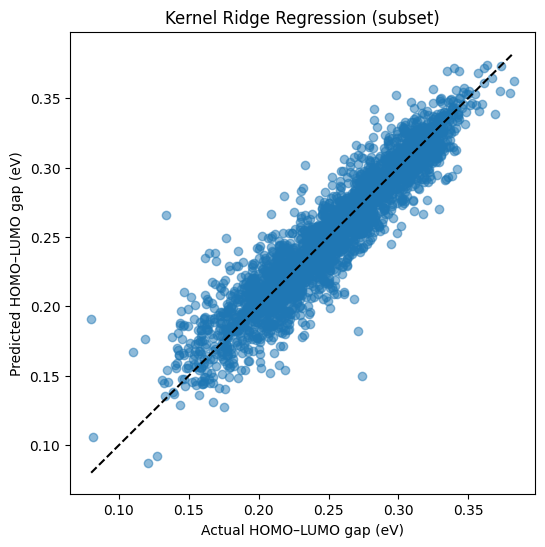

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Subsample dataset (IMPORTANT for KRR)
df_krr = df_ml.sample(n=15000, random_state=42)

# Features and target
X = df_krr.drop(columns=["gap"]).values
y = df_krr["gap"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling (mandatory for KRR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Kernel Ridge Regression model
krr = KernelRidge(
    kernel="laplacian",
    alpha=1e-6,
    gamma=1e-2
)

# Train model
krr.fit(X_train_scaled, y_train)

# Predict
y_pred_krr = krr.predict(X_test_scaled)

# R² score
r2_krr = r2_score(y_test, y_pred_krr)
print("KRR R² score:", r2_krr)

# Training set predictions
y_train_pred_krr = krr.predict(X_train_scaled)
r2_train_krr = r2_score(y_train, y_train_pred_krr)
print("KRR Training R²:", r2_train_krr)


# Parity plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_krr, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--", color="black"
)
plt.xlabel("Actual HOMO–LUMO gap (eV)")
plt.ylabel("Predicted HOMO–LUMO gap (eV)")
plt.title("Kernel Ridge Regression (subset)")
plt.show()


Epoch 1/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0081 - val_loss: 0.0011
Epoch 2/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.2048e-04 - val_loss: 7.0195e-04
Epoch 3/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0319e-04 - val_loss: 6.7117e-04
Epoch 4/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.2964e-04 - val_loss: 5.6088e-04
Epoch 5/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.1315e-04 - val_loss: 4.9878e-04
Epoch 6/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.7920e-04 - val_loss: 4.3736e-04
Epoch 7/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.3305e-04 - val_loss: 4.1712e-04
Epoch 8/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.1307e-04 - val_loss: 3.9263e-04
Epoch 9/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.8571e-04 - val_loss: 3.8540e-04
Epoch 10/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.2056e-04 - val_loss: 4.1050e-04
Epoch 11/300
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - l

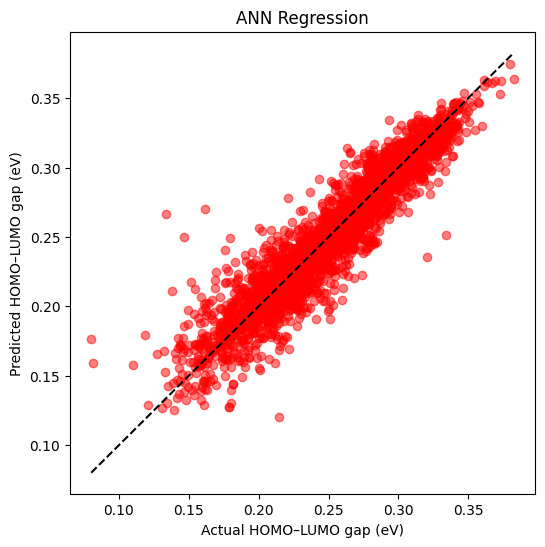

In [15]:
import tensorflow as tf
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Define simple feed-forward ANN
ann = tf.keras.models.Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),  # number of descriptors
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)  # output: HOMO-LUMO gap
])

# Compile model (Adam optimizer + MSE loss)
ann.compile(optimizer="adam", loss="mse")

# Train ANN
history = ann.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=300,
    batch_size=32,
    verbose=1
)

# Predict on test set
y_pred_ann = ann.predict(X_test_scaled).flatten()

# Compute R² score
r2_ann = r2_score(y_test, y_pred_ann)
print("ANN R² score:", r2_ann)

# Training set predictions
y_train_pred_ann = ann.predict(X_train_scaled).flatten()
r2_train_ann = r2_score(y_train, y_train_pred_ann)
print("ANN Training R²:", r2_train_ann)


# Parity plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ann, alpha=0.5, color="red")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "--", color="black")
plt.xlabel("Actual HOMO–LUMO gap (eV)")
plt.ylabel("Predicted HOMO–LUMO gap (eV)")
plt.title("ANN Regression")
plt.show()


In [11]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Load the CSV file with SMILES strings and band gap values
df = pd.read_csv("qm9(2).csv")

# Convert SMILES into RDKit molecule objects
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)

# List all RDKit descriptors
descriptor_list = [desc_name for desc_name, _ in Descriptors._descList]

# Calculate all descriptors for each molecule
for desc_name in descriptor_list:
    df[desc_name] = df["mol"].apply(lambda mol: Descriptors.__dict__[desc_name](mol) if mol is not None else np.nan)

# Remove molecules where some descriptors could not be calculated
df = df.dropna()

# Prepare features (X) and target (y)
X = df[descriptor_list]
y = df["gap"]

# Quick correlation check to see which descriptors are most related to band gap
corr = X.corrwith(y).abs().sort_values(ascending=False)
print("Top 10 correlated descriptors:\n", corr.head(10))

# Use SelectKBest to automatically choose the top 10 descriptors
selector = SelectKBest(score_func=f_regression, k=10)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
print("Selected features by SelectKBest:", list(selected_features))

# Split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# Train a Random Forest regressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
rf.fit(X_train, y_train)

# Make predictions on both training and test sets
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

# Evaluate the model using R² score
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
print(f"RF Training R²: {r2_train:.3f}")
print(f"RF Test R²: {r2_test:.3f}")

# You can now reuse X_selected for other models like KRR or ANN


/tmp/ipython-input-1102315705.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[desc_name] = df["mol"].apply(lambda mol: Descriptors.__dict__[desc_name](mol) if mol is not None else np.nan)
/tmp/ipython-input-1102315705.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[desc_name] = df["mol"].apply(lambda mol: Descriptors.__dict__[desc_name](mol) if mol is not None else np.nan)
/tmp/ipython-input-1102315705.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert`

Top 10 correlated descriptors:
 FractionCSP3     0.714814
HallKierAlpha    0.690995
SMR_VSA5         0.577387
VSA_EState2      0.561471
SMR_VSA10        0.537322
Chi1v            0.525361
Chi1n            0.525361
BertzCT          0.520328
BCUT2D_MRHI      0.516771
Chi2v            0.512536
dtype: float64
Selected features by SelectKBest: ['BCUT2D_MRHI', 'BertzCT', 'Chi1n', 'Chi1v', 'Chi2v', 'HallKierAlpha', 'SMR_VSA10', 'SMR_VSA5', 'VSA_EState2', 'FractionCSP3']
RF Training R²: 0.989
RF Test R²: 0.922


Random Forest R² score: 0.9055297112618361
RF Training R²: 0.9828397727069691


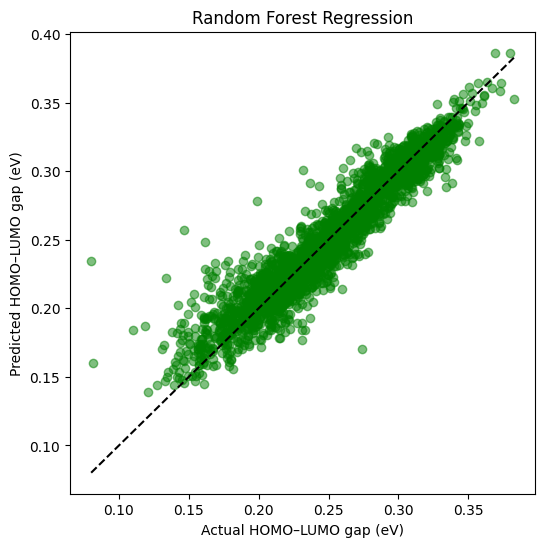

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Initialize Random Forest
rf = RandomForestRegressor(n_estimators=700, max_depth=20, min_samples_split=4, min_samples_leaf=1, max_features=1.0, random_state=42, n_jobs=-1)

# Train model
rf.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_rf = rf.predict(X_test_scaled)

# Compute R² score
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest R² score:", r2_rf)

# Training set predictions
y_train_pred_rf = rf.predict(X_train_scaled)
r2_train_rf = r2_score(y_train, y_train_pred_rf)
print("RF Training R²:", r2_train_rf)

# Plot predicted vs actual HOMO-LUMO gaps
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color="green")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "--", color="black")
plt.xlabel("Actual HOMO–LUMO gap (eV)")
plt.ylabel("Predicted HOMO–LUMO gap (eV)")
plt.title("Random Forest Regression")
plt.show()
